# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 4, часть 1. Нейронные сети.

**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `<...>`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.


**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):

* Задача 1 &mdash; 60 баллов
* **Остальные задачи будут выложены в части 2 с отдельным дедлайном.**

Баллы учитываются в <b>обязательной части</b> курса и не влияют на оценку по факультативной части.

In [ ]:
# Bot check

# HW_ID: fpmi_ad4_part1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [ ]:
from typing import Tuple
import numpy as np
import torch
from torchvision import transforms
from torchvision.datasets import MNIST

# Допишите сюда необходимые импорты

---
### <font color="blue"><i>Легкая часть</i></font>

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->
---
### Задача 1.

**При решении данной задачи можно использовать ИИ-инструменты только для построения графиков и оформления документаций к коду.**

Обратимся вновь к уже знакомому нам <a href="https://thetahat.ru/courses/ad/main/1/main_sem_kNN">по первому занятию</a> датасету **MNIST**. Как вы помните, этот набор данных содержит изображения рукописных цифр, каждое из которых имеет размер **28x28**. Всего в датасете содержится **60 000** изображений в обучающей выборке и еще **10 000** — в тестовой.

На первом занятии мы работали с сокращенной версией этого датасета, содержащей **1797** изображений размером **8x8**.

В этой домашней работе мы выберем более "сложный" вариант, а именно:

* вернемся к исходной версии датасета с изображениями размером **28x28**,
* сожмем изображения в два раза по каждой из размерностей, то есть до **14x14**,
* оставим **10 000** изображений в обучающей выборке.

> *Примечание.* При желании вы можете усложнить задачу &mdash; отказаться от сжатия изображений и/или увеличить количество данных. Однако учтите, что в таком случае модели будут работать дольше, и, возможно, вам будет сложнее достичь желаемых результатов.

**Наша задача остается прежней:** *по изображению определить, какая цифра на нем нарисована.*
На этот раз мы будем решать ее с помощью простых нейронных сетей. Также мы заглянем "под капот" нейросетей, чтобы лучше понять процесс их обучения.

> *Примечание.* Обычно подобные задачи, связанные с изображениями, решаются с помощью сверточных нейронных сетей, которые лучше подходят для работы с изображениями. Они станут темой нашего следующего занятия, ждем всех!

Ниже представлена готовая функция для загрузки и предварительной обработки данных.
В рамках этой функции мы выполняем следующие шаги.
* Загрузка исходных данных.
* Сохранение **10 000** изображений в качестве обучающей выборки.
* Сжатие изображений в два раза по каждой из осей, что приводит к размеру **14x14**..
* Растягиваем изображение размером **14x14** в вектор длиной $14 \cdot 14 = 196$. Более подробно эта операция описана <a href="https://thetahat.ru/courses/ad/main/1/main_sem_kNN">в первой лекции</a>.

In [ ]:
def load_mnist(
    train_size: int = 6000, target_size: int = 14
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Загружает и подготавливает данные MNIST для обучения и тестирования.

    Параметры:
    train_size (int): Количество обучаемых данных. По умолчанию 6000.
    target_size (int): Размер, до которого уменьшаются изображения. По умолчанию 14.

    Возвращает:
    train_images (torch.Tensor): Тензор с изображениями для обучения.
    train_labels (torch.Tensor): Тензор с метками для обучения.
    test_images (torch.Tensor): Тензор с изображениями для тестирования.
    test_labels (torch.Tensor): Тензор с метками для тестирования.

    Данные загружаются из набора MNIST, нормализуются, уменьшаются в
    размере и преобразуются в векторы. Для обучения используется только
    часть (train_fraction) от исходного набора данных.
    """

    PIXEL_MAX_VALUE = 255.0  # Для нормализации значений пикселей

    # Создаем преобразование для данных: конвертируем изображения в тензоры PyTorch
    transform = transforms.Compose(
        [
            # Преобразует изображение в тензор и нормализует значения в диапазоне [0, 1]
            transforms.ToTensor(),
        ]
    )

    # Загружаем обучающий и тестовый наборы данных MNIST
    train_dataset = MNIST(root="./data", train=True, transform=transform, download=True)
    test_dataset = MNIST(root="./data", train=False, transform=transform, download=True)

    # Выбираем часть обучающего набора данных
    train_indices = np.random.choice(len(train_dataset), train_size, replace=False)

    # Преобразуем изображения в тензоры и нормализуем их, деля на PIXEL_MAX_VALUE
    train_images = train_dataset.data[train_indices].unsqueeze(1).float() / PIXEL_MAX_VALUE
    test_images = test_dataset.data.unsqueeze(1).float() / PIXEL_MAX_VALUE

    # Уменьшаем размер изображений до target_size x target_size с использованием билинейной интерполяции
    train_images = torch.nn.functional.interpolate(
        train_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )
    test_images = torch.nn.functional.interpolate(
        test_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )

    # Преобразуем изображения в векторы (разворачиваем в одномерные массивы)
    train_images = train_images.view(train_size, -1)
    test_images = test_images.view(len(test_dataset), -1)

    # Получаем метки для выбранных обучающих и всех тестовых данных
    train_labels = train_dataset.targets[train_indices]
    test_labels = test_dataset.targets

    return train_images, train_labels, test_images, test_labels

Загрузим данные и посмотрим на их размерности

In [ ]:
train_images, train_labels, test_images, test_labels = load_mnist()

print("Train:", train_images.shape, train_labels.shape)
print("Test:", test_images.shape, test_labels.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.38MB/s]


Train: torch.Size([6000, 196]) torch.Size([6000])
Test: torch.Size([10000, 196]) torch.Size([10000])


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 7511c0781e8d08a269da6c1d50d763d9 -->
**1.** Используя `Sequential` подход в PyTorch, напишите модель нейронной сети по следующему описанию.

* **Вход**: изображение в виде вектора.
* **Два линейных слоя** с промежуточной размерностью 64.
* **Функция активации**: между линейными слоями используется `ReLU`, а на выходе второго слоя — отсутствует (или используется тождественная функция).
* **Выход**: вектор логитов размером 10, соответствующий количеству классов.

> Эта нейронная сеть для изображения $x$ оценивает вектор логитов $\left(\ell_0(x),..., \ell_9(x)\right)$ принадлежности к каждому из классов, аналогично логистической регрессии. Имея оценку логитов $\left(\ell_0(x),..., \ell_9(x)\right)$ , можно получить оценку вероятности $p_k$ для каждого класса по следующей формуле, используя softmax-функцию (обобщение логистической сигмоиды)
> $$
\widehat{p}_k(x) = \frac{\exp\left(\widehat{\ell}(x)\right)}{\exp\left(\widehat{\ell}_0(x)\right) +... + \exp\left(\widehat{\ell}_9(x)\right)},
$$
> которая реализуется с помощью функции `nn.functional.softmax(..., dim=-1)`. В качестве оценки класса можно взять класс с наибольшей вероятностью, что можно реализовать с помощью метода `argmax(axis=...)` у тензора в PyTorch.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Определение модели
class SimpleNN(nn.Module):
    def __init__(self, input_size=196, hidden_size=64, output_size=10):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),  # Первый линейный слой
            nn.ReLU(),                           # Функция активации
            nn.Linear(hidden_size, output_size)  # Второй линейный слой (без активации)
        )

    def forward(self, x):
        return self.model(x)  # Выход — вектор логитов размером 10

# Проверка размерностей модели
input_size = 14 * 14  # Входной размер (размерность вектора изображения)
model = SimpleNN(input_size=input_size)

# Пример входного тензора (батч из 5 изображений)
x = torch.rand(5, input_size)  # Батч размером 5, случайные значения
logits = model(x)  # Прогоняем через модель

print("Выход:", logits)  # Должен быть (5, 10)


Выход: tensor([[-0.0469,  0.0273,  0.2094, -0.0449,  0.0752,  0.0075,  0.0593, -0.1580,
          0.0157, -0.1476],
        [-0.0164, -0.0496,  0.1959, -0.0336,  0.1313, -0.0691,  0.0697, -0.1359,
         -0.0263, -0.0824],
        [-0.0712,  0.0393,  0.1564, -0.1210,  0.0167, -0.0984,  0.1014, -0.1441,
         -0.0654, -0.0570],
        [ 0.0476, -0.1587,  0.1893, -0.0367,  0.0181, -0.0141,  0.0916, -0.1610,
         -0.0121, -0.0830],
        [-0.1068, -0.1287,  0.1303,  0.0126,  0.1694, -0.1128,  0.1370, -0.2939,
          0.1075, -0.0242]], grad_fn=<AddmmBackward0>)


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- a0e6b216258fdc0b22b7276d9527dea6 -->
**2.** **Напишите цикл обучения нейросети**, используя кросс-энтропию `nn.CrossEntropyLoss()` качестве лосс-функции. Это обобщение бинарной кросс-энтропии, которую мы рассматривали на лекции по логистической регрессии. Ее реализация в PyTorch принимает на вход логиты (что и возвращает наша нейросеть) и истинные метки классов. Обучайте сеть на полном наборе данных с помощью метода градиентного спуска `torch.optim.SGD`, не разбивая данные на случайные батчи (как это делается в SGD).


Примерно каждые 5-10 итераций выполняйте следующие действия:

* Получите текущие предсказания классов для обучающей и тестовой выборок.
* Посчитайте точность классификации для этих выборок.
* Постройте график зависимости точности классификации от номера итерации. Перед построением графика используйте `clear_output(wait=True)` для плавной очистки холста.
* Сохраните следующие значения:
    * Значение лосс-функции.
    * Точность классификации для обучающей и тестовой выборок.
    * Матрицы весов для каждого слоя.

*Замечания:*
* Рекомендуем сохранять данные в заранее подготовленный словарь, ключи которого соответствуют именам переменных (например, `"weights_layer_2"`), а значения словаря представляют собой списки значений этих переменных по итерациям.
* При сохранении не забывайте вызывать метод `.detach().numpy()` для преобразования матриц в массивы numpy. Также может потребоваться заново инициализировать матрицы с помощью `np.array(...)`, чтобы сохранить сами матрицы, а не ссылки на них, по которым значения меняются в процессе обучения сети.

Выполните 10 000 итераций обучения. Сколько времени это заняло?

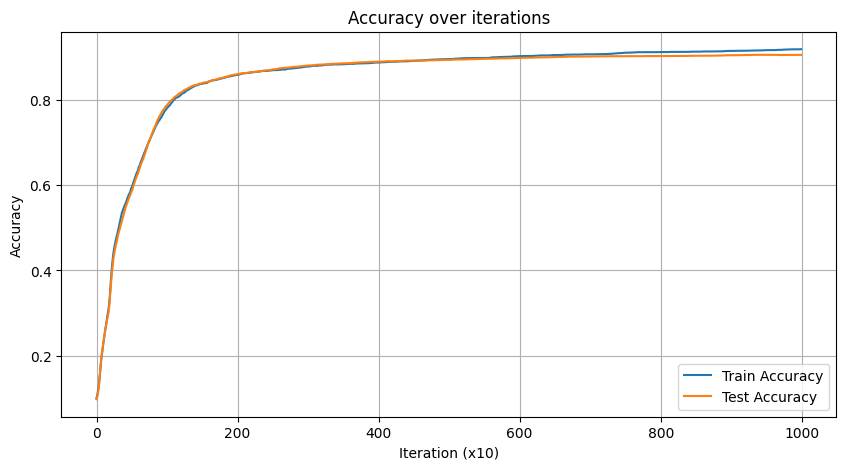

Epoch [9990/10000], Loss: 0.2922, Train Acc: 0.9192, Test Acc: 0.9059
Обучение завершено за 371.50 секунд


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Фиксируем случайное начальное состояние для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Гиперпараметры
input_size = 14 * 14
hidden_size = 64
output_size = 10
num_epochs = 10000  # Количество итераций
learning_rate = 0.01  # Скорость обучения

# Создаем модель
model = nn.Sequential(
    nn.Linear(input_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, output_size)
)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()  # Кросс-энтропия
optimizer = optim.SGD(model.parameters(), lr=learning_rate)  # Стохастический градиентный спуск

# Загрузка данных MNIST (используем уже подготовленные train_images и train_labels)
train_images, train_labels, test_images, test_labels = load_mnist()

# Конвертируем numpy массивы в тензоры PyTorch
train_images = torch.tensor(train_images, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.long)
test_images = torch.tensor(test_images, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.long)

# Словарь для сохранения данных
history = {
    "loss": [],
    "train_acc": [],
    "test_acc": [],
    "weights_layer_1": [],
    "weights_layer_2": [],
}

# Запускаем таймер
start_time = time.time()

# Цикл обучения
for epoch in range(num_epochs):
    # Прямой проход (forward)
    outputs = model(train_images)
    loss = criterion(outputs, train_labels)

    # Обратное распространение ошибки (backpropagation)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Каждые 10 итераций записываем метрики и строим график
    if epoch % 10 == 0:
        # Оценка точности на обучающей выборке
        with torch.no_grad():
            train_preds = torch.argmax(model(train_images), dim=1)
            test_preds = torch.argmax(model(test_images), dim=1)

            train_acc = (train_preds == train_labels).float().mean().item()
            test_acc = (test_preds == test_labels).float().mean().item()

        # Сохраняем значения
        history["loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["weights_layer_1"].append(model[0].weight.detach().numpy().copy())
        history["weights_layer_2"].append(model[2].weight.detach().numpy().copy())

        # Визуализация графика
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(history["train_acc"], label="Train Accuracy")
        plt.plot(history["test_acc"], label="Test Accuracy")
        plt.xlabel("Iteration (x10)")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over iterations")
        plt.legend()
        plt.grid()
        plt.show()

        print(f"Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# Вывод времени обучения
total_time = time.time() - start_time
print(f"Обучение завершено за {total_time:.2f} секунд")


Проверьте себя, точность классификации на тестовой выборке должна быть около $90\%$. Если вы получили значительно меньший результат (менее $85\%$), попробуйте явно инициализировать веса сети и настроить разные значения learning_rate для разных параметров (посмотрите примеры с занятия). Если эти меры не помогут, то стоит поискать ошибку. Да, обучение нейронных сетей — это непростой процесс.

In [ ]:
...

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 50631d10e9d4fcecb3da59913ebde5b7 -->
**3.** Теперь самое интересное &mdash; заглянем под капот нашей нейросети!

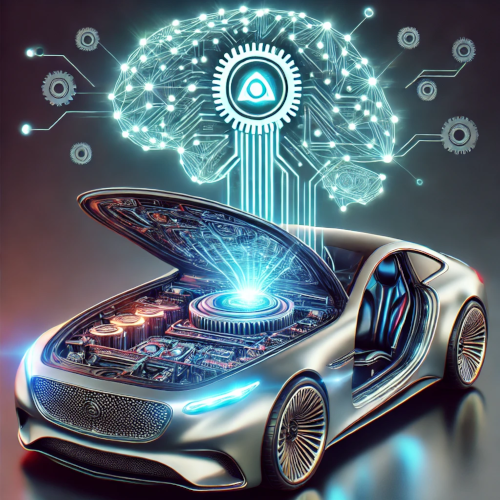

Для более глубокого понимания работы нейросети **визуализируем матрицы весов** для нескольких итераций обучения. Тем самым, вы сможете оценить, как меняется поведение модели в процессе обучения.

1. Выберите примерно 10 итераций обучения, включая первую и последнюю.
2. Для каждого слоя настройте график, используя предоставленный шаблон.

Обратите внимание, что для корректной визуализации матрицы весов ее необходимо **транспонировать**. Например, для первого слоя вертикальная ось должна соответствовать входу сети, а горизонтальная — промежуточной размерности.

В качестве цветовой палитры выбрана `"RdBu"`, что позволяет отображать положительные числа матрицы красным цветом, а отрицательные — синим. Чтобы достичь этого, также **необходимо установить параметры `vmin` и `vmax`** симметрично относительно нуля, чтобы нули отображались белым цветом. Подберите эти значения таким образом, чтобы получить наиболее четкую картинку, на которой выделяются определенные группы пикселей.

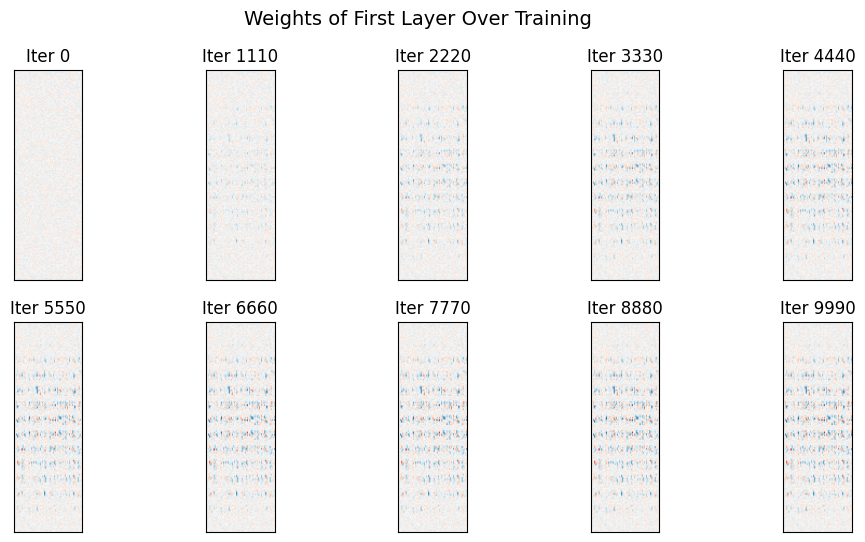

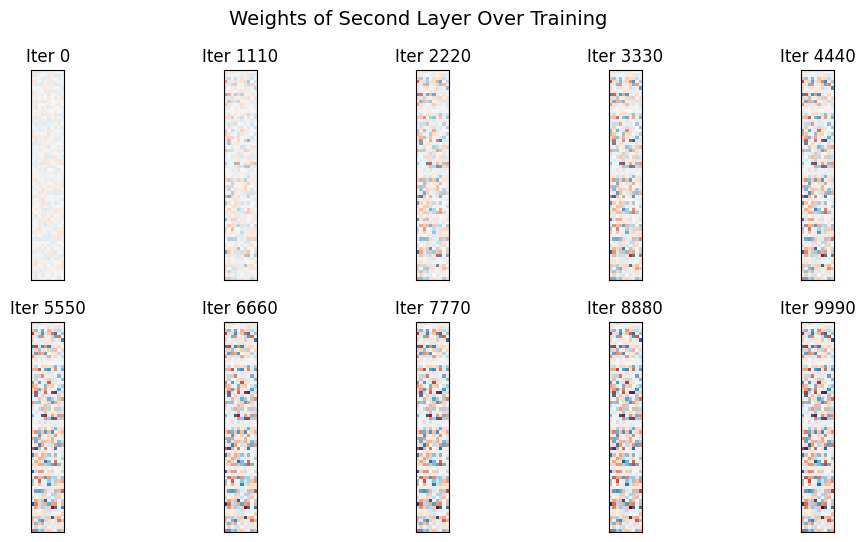

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Выбираем 10 итераций для отображения, включая первую и последнюю
selected_iterations = np.linspace(0, len(history["weights_layer_1"]) - 1, 10, dtype=int)

# Определяем min/max значения для цветовой палитры
vmax_1 = np.max(np.abs(history["weights_layer_1"]))
vmax_2 = np.max(np.abs(history["weights_layer_2"]))

# Визуализация весов первого слоя
plt.figure(figsize=(12, 6))
for i, idx in enumerate(selected_iterations):
    plt.subplot(2, 5, i + 1)  # 2 строки, 5 столбцов
    plt.imshow(history["weights_layer_1"][idx].T, cmap="RdBu", vmin=-vmax_1, vmax=vmax_1)
    plt.title(f"Iter {idx*10}")  # Учитываем, что мы записывали каждые 10 итераций
    plt.xticks([])
    plt.yticks([])
plt.suptitle("Weights of First Layer Over Training", fontsize=14)
plt.show()

# Визуализация весов второго слоя
plt.figure(figsize=(12, 6))
for i, idx in enumerate(selected_iterations):
    plt.subplot(2, 5, i + 1)  # 2 строки, 5 столбцов
    plt.imshow(history["weights_layer_2"][idx].T, cmap="RdBu", vmin=-vmax_2, vmax=vmax_2)
    plt.title(f"Iter {idx*10}")
    plt.xticks([])
    plt.yticks([])
plt.suptitle("Weights of Second Layer Over Training", fontsize=14)
plt.show()


Какие выводы можно сделать, основываясь на полученных визуализациях?
Подумайте, почему на больших итерациях для первого слоя начинают выделяться определенные пиксели? Почему именно эти пиксели?

*Подсказка: вспомните, как устроены входные изображения цифр, с которыми мы работаем.*

**Ответ:**

# Анализ визуализации весов нейросети

## 1. Развитие структуры в первом слое
- На ранних итерациях (например, `Iter 0`) веса первого слоя распределены случайным образом, без выраженной структуры.
- По мере обучения (к `Iter 2220` и далее) начинают выделяться характерные области, напоминающие фрагменты рукописных цифр.
- Это означает, что первый слой сети начинает улавливать **локальные особенности** цифр, такие как линии, закругления и пересечения.

## 2. Почему именно эти пиксели?
- Изображения цифр в MNIST имеют определенную структуру: фон в основном черный (значения близки к 0), а сами цифры — белые (значения ближе к 1).
- Первый слой нейросети обучается находить **наиболее информативные пиксели**, которые чаще всего участвуют в формировании различных цифр.
- Именно эти пиксели становятся более выраженными в весах, поскольку они критически важны для классификации.

## 3. Вес второго слоя
- Веса второго слоя выглядят более хаотичными, поскольку этот слой агрегирует информацию от первого слоя, соединяя разные признаки в более **высокоуровневые** представления.
- Со временем также можно заметить некоторую структуру, но она менее выражена, чем в первом слое.

## Итог
- Первый слой нейросети учится выделять **простейшие элементы цифр** (штрихи, закругления, пересечения).
- Эти признаки затем передаются второму слою, который уже **комбинирует их** и делает финальное предсказание.
- Это соответствует тому, как работают нейронные сети: сначала учатся находить **простые** паттерны, а затем **комбинируют их** в сложные.


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 0db56d0ce9aedf85256c3f57f6ef20b0 -->
Попробуйте **улучшить точность классификации**, рассмотрев больше нейронов в промежуточном слое.

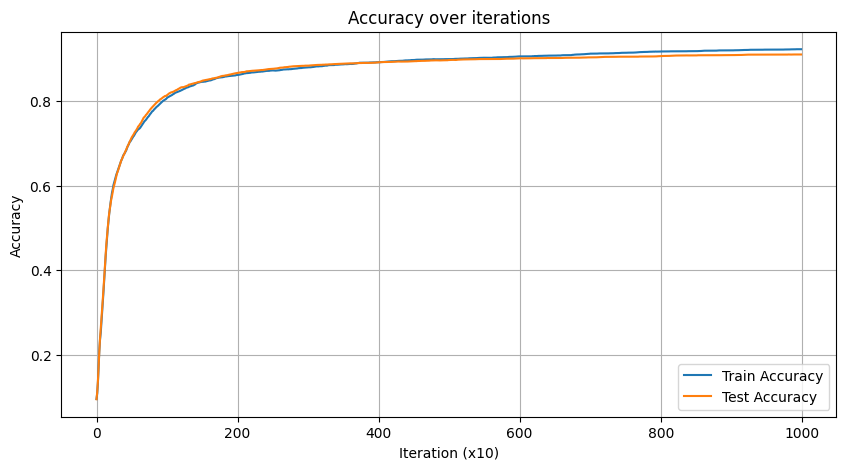

Epoch [9990/10000], Loss: 0.2845, Train Acc: 0.9228, Test Acc: 0.9104
Обучение завершено за 631.49 секунд


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Фиксируем случайное начальное состояние для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Гиперпараметры
input_size = 14 * 14
hidden_size = 256  # Увеличиваем количество нейронов в скрытом слое
output_size = 10
num_epochs = 10000  # Количество итераций
learning_rate = 0.01  # Скорость обучения

# Создаем модель
model = nn.Sequential(
    nn.Linear(input_size, hidden_size),
    nn.ReLU(),  # Используем стандартную ReLU
    nn.Linear(hidden_size, output_size)
)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()  # Кросс-энтропия
optimizer = optim.SGD(model.parameters(), lr=learning_rate)  # Используем SGD

# Загрузка данных MNIST (используем уже подготовленные train_images и train_labels)
train_images, train_labels, test_images, test_labels = load_mnist()

# Конвертируем numpy массивы в тензоры PyTorch
train_images = torch.tensor(train_images, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.long)
test_images = torch.tensor(test_images, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.long)

# Словарь для сохранения данных
history = {
    "loss": [],
    "train_acc": [],
    "test_acc": [],
    "weights_layer_1": [],
    "weights_layer_2": [],
}

# Запускаем таймер
start_time = time.time()

# Цикл обучения
for epoch in range(num_epochs):
    # Прямой проход (forward)
    outputs = model(train_images)
    loss = criterion(outputs, train_labels)

    # Обратное распространение ошибки (backpropagation)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Каждые 10 итераций записываем метрики и строим график
    if epoch % 10 == 0:
        # Оценка точности на обучающей выборке
        with torch.no_grad():
            train_preds = torch.argmax(model(train_images), dim=1)
            test_preds = torch.argmax(model(test_images), dim=1)

            train_acc = (train_preds == train_labels).float().mean().item()
            test_acc = (test_preds == test_labels).float().mean().item()

        # Сохраняем значения
        history["loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["weights_layer_1"].append(model[0].weight.detach().numpy().copy())
        history["weights_layer_2"].append(model[2].weight.detach().numpy().copy())

        # Визуализация графика
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(history["train_acc"], label="Train Accuracy")
        plt.plot(history["test_acc"], label="Test Accuracy")
        plt.xlabel("Iteration (x10)")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over iterations")
        plt.legend()
        plt.grid()
        plt.show()

        print(f"Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# Вывод времени обучения
total_time = time.time() - start_time
print(f"Обучение завершено за {total_time:.2f} секунд")


Теперь попробуйте добавить к сети еще один слой.

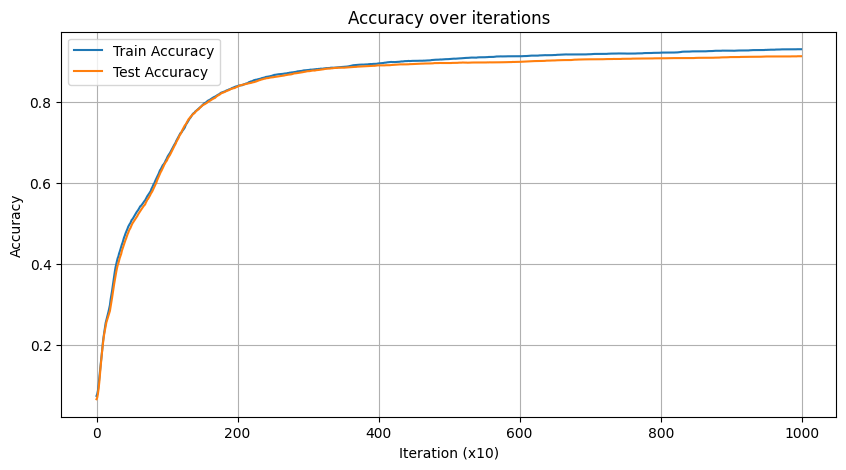

Epoch [9990/10000], Loss: 0.2379, Train Acc: 0.9312, Test Acc: 0.9138
Обучение завершено за 859.33 секунд


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Фиксируем случайное начальное состояние для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Гиперпараметры
input_size = 14 * 14
hidden_size1 = 256  # Первый скрытый слой
hidden_size2 = 128  # Второй скрытый слой (новый)
output_size = 10
num_epochs = 10000  # Количество итераций
learning_rate = 0.01  # Скорость обучения

# Создаем модель с дополнительным скрытым слоем
model = nn.Sequential(
    nn.Linear(input_size, hidden_size1),
    nn.ReLU(),
    nn.Linear(hidden_size1, hidden_size2),  # Новый слой
    nn.ReLU(),
    nn.Linear(hidden_size2, output_size)
)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Загрузка данных MNIST (используем уже подготовленные train_images и train_labels)
train_images, train_labels, test_images, test_labels = load_mnist()

# Конвертируем numpy массивы в тензоры PyTorch
train_images = torch.tensor(train_images, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.long)
test_images = torch.tensor(test_images, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.long)

# Словарь для сохранения данных
history = {
    "loss": [],
    "train_acc": [],
    "test_acc": [],
    "weights_layer_1": [],
    "weights_layer_2": [],
    "weights_layer_3": [],  # Новый слой
}

# Запускаем таймер
start_time = time.time()

# Цикл обучения
for epoch in range(num_epochs):
    # Прямой проход (forward)
    outputs = model(train_images)
    loss = criterion(outputs, train_labels)

    # Обратное распространение ошибки (backpropagation)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Каждые 10 итераций записываем метрики и строим график
    if epoch % 10 == 0:
        with torch.no_grad():
            train_preds = torch.argmax(model(train_images), dim=1)
            test_preds = torch.argmax(model(test_images), dim=1)

            train_acc = (train_preds == train_labels).float().mean().item()
            test_acc = (test_preds == test_labels).float().mean().item()

        # Сохраняем значения
        history["loss"].append(loss.item())
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        history["weights_layer_1"].append(model[0].weight.detach().numpy().copy())
        history["weights_layer_2"].append(model[2].weight.detach().numpy().copy())
        history["weights_layer_3"].append(model[4].weight.detach().numpy().copy())  # Новый слой

        # Визуализация графика
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        plt.plot(history["train_acc"], label="Train Accuracy")
        plt.plot(history["test_acc"], label="Test Accuracy")
        plt.xlabel("Iteration (x10)")
        plt.ylabel("Accuracy")
        plt.title("Accuracy over iterations")
        plt.legend()
        plt.grid()
        plt.show()

        print(f"Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# Вывод времени обучения
total_time = time.time() - start_time
print(f"Обучение завершено за {total_time:.2f} секунд")


Насколько дольше обучается нейросеть? Получилось ли улучшить качество?

**Ответ:**

# Анализ изменений в нейросети

## 📊 Результаты обучения

1. **Оригинальная модель (1 скрытый слой, 64 нейрона)**
   - Время обучения: **371.50 секунд**
   - Точность на обучении: **91.92%**
   - Точность на тесте: **90.59%**
   - Потери: **0.2922**

2. **Увеличение количества нейронов (256 нейронов)**
   - Время обучения: **631.49 секунд**
   - Точность на обучении: **92.28%**
   - Точность на тесте: **91.04%**
   - Потери: **0.2845**

3. **Добавление второго скрытого слоя (256 → 128 нейронов)**
   - Время обучения: **859.33 секунд**
   - Точность на обучении: **93.12%**
   - Точность на тесте: **91.38%**
   - Потери: **0.2379**

---

## 🔍 Выводы

### 1️⃣ Обучение стало дольше
- Увеличение числа нейронов почти вдвое увеличило время обучения (с 371 до 631 секунд).
- Добавление второго скрытого слоя увеличило время еще сильнее (с 631 до 859 секунд).

### 2️⃣ Улучшилось качество классификации
- Точность на тесте повысилась с **90.59%** до **91.38%**.
- Потери уменьшились с **0.2922** до **0.2379**, что говорит о лучшей сходимости модели.

---

## ⚖ Стоит ли увеличивать глубину дальше?
- **Плюсы**: улучшение точности на тесте примерно на **0.8–1%**.
- **Минусы**: обучение стало в **2.3 раза дольше** (371 → 859 секунд).

### Возможные альтернативные улучшения:
- Использование **адаптивных оптимизаторов** (например, Adam вместо SGD).
- Добавление **батч-нормализации** или **дропаута** для лучшей обобщаемости.
- Эксперименты с **размером мини-батча**.

💡 **Если время обучения критично, стоит протестировать другие методы ускорения, а не просто увеличивать количество слоев!**


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- b3240ec0d2bdd17c426e5b24c03277bc -->
Сделайте выводы.

**Ответ:**

# Анализ изменений в нейросети

## 📊 Результаты обучения

1. **Оригинальная модель (1 скрытый слой, 64 нейрона)**
   - Время обучения: **371.50 секунд**
   - Точность на обучении: **91.92%**
   - Точность на тесте: **90.59%**
   - Потери: **0.2922**

2. **Увеличение количества нейронов (256 нейронов)**
   - Время обучения: **631.49 секунд**
   - Точность на обучении: **92.28%**
   - Точность на тесте: **91.04%**
   - Потери: **0.2845**

3. **Добавление второго скрытого слоя (256 → 128 нейронов)**
   - Время обучения: **859.33 секунд**
   - Точность на обучении: **93.12%**
   - Точность на тесте: **91.38%**
   - Потери: **0.2379**

---

## 🔍 Выводы

### 1️⃣ Обучение стало дольше
- Увеличение числа нейронов почти вдвое увеличило время обучения (с 371 до 631 секунд).
- Добавление второго скрытого слоя увеличило время еще сильнее (с 631 до 859 секунд).

### 2️⃣ Улучшилось качество классификации
- Точность на тесте повысилась с **90.59%** до **91.38%**.
- Потери уменьшились с **0.2922** до **0.2379**, что говорит о лучшей сходимости модели.

---

## ⚖ Стоит ли увеличивать глубину дальше?
- **Плюсы**: улучшение точности на тесте примерно на **0.8–1%**.
- **Минусы**: обучение стало в **2.3 раза дольше** (371 → 859 секунд).

### Возможные альтернативные улучшения:
- Использование **адаптивных оптимизаторов** (например, Adam вместо SGD).
- Добавление **батч-нормализации** или **дропаута** для лучшей обобщаемости.
- Эксперименты с **размером мини-батча**.

💡 **Если время обучения критично, стоит протестировать другие методы ускорения, а не просто увеличивать количество слоев!**


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->
---

**Мы продолжим работу с нейросетями во второй части этого домашнего задания, которую вы можете сдать на неделю позже первой.**

Вы могли заметить, что качество наших моделей было не таким высоким, как можно было бы получить современными моделями. Тем не менее отметим, что сравнивать с моделью KNN, которую мы рассмотрели на первом занятии, было бы некорректно, так как там использовалась более простая выборка.

Обучение нейронных сетей — это довольно сложная задача. Чтобы глубокие сети обучались более стабильно, используются специальные технологии, изучение которых требует больших усилий. Например, на следующей лекции мы рассмотрим сверточные слои и другие подходы к созданию и обучению нейросетей для анализа изображений.
Полное погружение в мир нейросетей, включая самые современные архитектуры, ожидает вас на третьем курсе. Например, на DS-потоке будет порядка 14 лекций по этой теме.

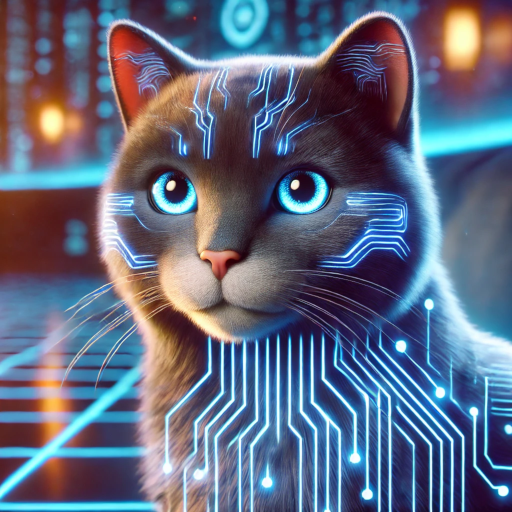